In [3]:
# --- 라이브러리 불러오기 ---
import pandas as pd               # 표(데이터프레임) 다루는 핵심 도구
import numpy as np                # 숫자 계산 도구
import matplotlib.pyplot as plt   # 그래프 그리기
import seaborn as sns             # 더 예쁜 그래프
from ucimlrepo import fetch_ucirepo   # UCI 데이터 받아오는 도구
from pathlib import Path 

# UCI 문서(heart-disease.names) 기준 14개 컬럼 순서
COLS = ["age","sex","cp","trestbps","chol","fbs","restecg",
        "thalach","exang","oldpeak","slope","ca","thal","target"]

# 프로젝트 루트의 data 폴더 찾기 (노트북이 notebooks/ 안에 있어도 OK)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_dir = ROOT / "data"

files = ["processed.cleveland.data", "processed.hungarian.data",
         "processed.switzerland.data", "processed.va.data"]

# 4개 파일을 각각 읽어서(헤더 없음, '?'는 결측값으로 처리) 하나로 합치기
frames = [pd.read_csv(data_dir / f, header=None, names=COLS, na_values="?")
          for f in files]
df = pd.concat(frames, ignore_index=True)

# 모든 값을 숫자형으로 변환 (안전장치)
df = df.apply(pd.to_numeric, errors="coerce")

# 타깃 이진화: 0=정상, 1~4=심장병 → 1
df["target"] = (df["target"] > 0).astype(int)

print("합쳐진 데이터 크기 (행, 열):", df.shape)
df.head()

합쳐진 데이터 크기 (행, 열): (920, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    float64
 1   sex       920 non-null    float64
 2   cp        920 non-null    float64
 3   trestbps  861 non-null    float64
 4   chol      890 non-null    float64
 5   fbs       830 non-null    float64
 6   restecg   918 non-null    float64
 7   thalach   865 non-null    float64
 8   exang     865 non-null    float64
 9   oldpeak   858 non-null    float64
 10  slope     611 non-null    float64
 11  ca        309 non-null    float64
 12  thal      434 non-null    float64
 13  target    920 non-null    int32  
dtypes: float64(13), int32(1)
memory usage: 97.2 KB


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,920.000000,920.000000,920.000000,861.000000,890.000000,830.000000,918.000000,865.000000,865.000000,858.000000,611.000000,309.000000,434.000000,920.000000
mean,53.510870,0.789130,3.250000,132.132404,199.130337,0.166265,0.604575,137.545665,0.389595,0.878788,1.770867,0.676375,5.087558,0.553261
std,9.424685,0.408148,0.930969,19.066070,110.780810,0.372543,0.805827,25.926276,0.487941,1.091226,0.619256,0.935653,1.919075,0.497426
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,1.000000,0.000000,3.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,175.000000,0.000000,0.000000,120.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,223.000000,0.000000,0.000000,140.000000,0.000000,0.500000,2.000000,0.000000,6.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,268.000000,0.000000,1.000000,157.000000,1.000000,1.500000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


target
1    0.553261
0    0.446739
Name: proportion, dtype: float64


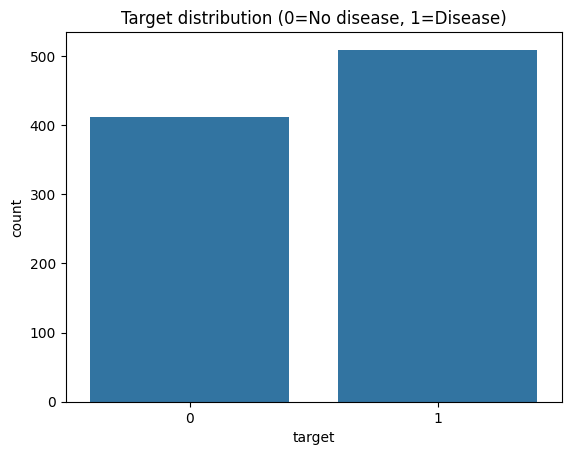

In [6]:
dist = df["target"].value_counts(normalize=True)
print(dist)

sns.countplot(x="target", data=df)
plt.title("Target distribution (0=No disease, 1=Disease)")
plt.show()

In [7]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(1),
}).sort_values("missing_count", ascending=False)
print(missing)
print("\n전체 결측 비율: {:.2f}%".format(df.isna().sum().sum() / df.size * 100))

          missing_count  missing_pct
ca                  611         66.4
thal                486         52.8
slope               309         33.6
fbs                  90          9.8
oldpeak              62          6.7
trestbps             59          6.4
thalach              55          6.0
exang                55          6.0
chol                 30          3.3
restecg               2          0.2
age                   0          0.0
sex                   0          0.0
cp                    0          0.0
target                0          0.0

전체 결측 비율: 13.66%


In [8]:
for col in ["chol", "trestbps"]:
    print(f"{col} == 0 인 행 수: {(df[col] == 0).sum()} 개")

chol == 0 인 행 수: 172 개
trestbps == 0 인 행 수: 1 개


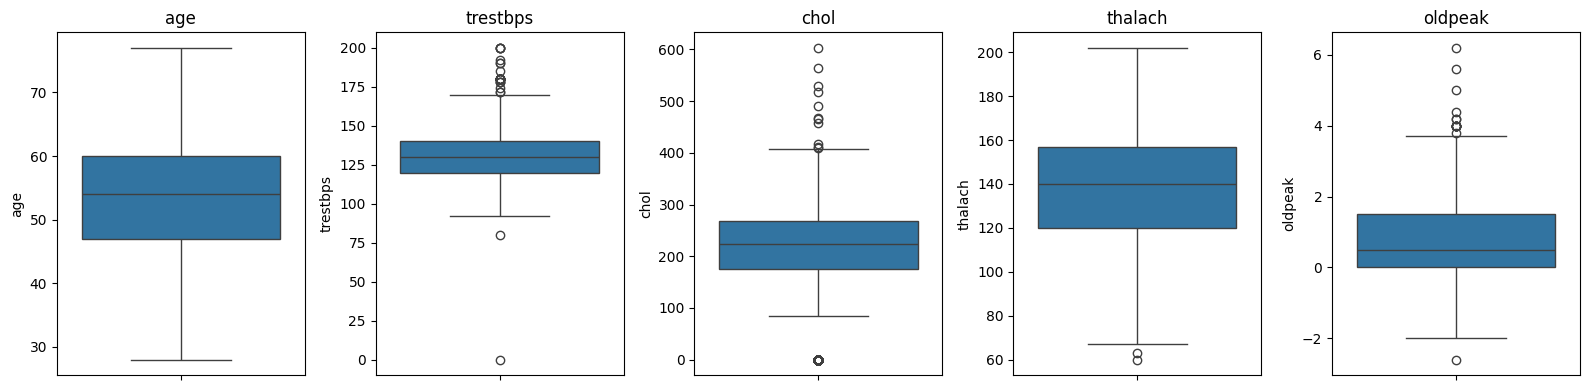

=== IQR 기준 이상치 개수 ===
age: 0 개
trestbps: 28 개
chol: 183 개
thalach: 2 개
oldpeak: 16 개


In [9]:
continuous = ["age", "trestbps", "chol", "thalach", "oldpeak"]

# (1) 박스플롯으로 눈으로 확인
fig, axes = plt.subplots(1, len(continuous), figsize=(16, 4))
for ax, col in zip(axes, continuous):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# (2) IQR 방식으로 이상치 개수 세기
def count_outliers_iqr(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()

print("=== IQR 기준 이상치 개수 ===")
for col in continuous:
    print(f"{col}: {count_outliers_iqr(df[col])} 개")

## EDA 핵심 발견

**1. 데이터 개요**
- 920행 × 14열. 4개 출처(Cleveland·Hungary·Switzerland·VA) 통합본.
- 타깃 이진화(0=정상 / 1=심장병). 분포 44.7% : 55.3% → 비교적 균형.

**2. 결측값 (info 기준)**
- 심각: `ca` 66%, `thal` 53%, `slope` 34%.
- 중간~경미: `fbs` 10%, `oldpeak` 7%, `trestbps` 6%, `thalach`·`exang` 6%, `chol` 3%, `restecg` 0.2%.
- 원인: 출처(병원)별로 특정 검사를 안 해서 컬럼이 통째로 비는 패턴.

**3. 숨은 결측값 (0으로 위장)**
- `chol`=0 이 **172개** → 명시적 결측 30개와 합쳐 실제 결측 ≈ 202개(22%). 겉보기 3.3%를 크게 과소평가.
- `trestbps`=0 은 1개.
- → 0을 NaN으로 바꾼 뒤 처리.

**4. 이상치 / 특이값**
- `age` 0개, `trestbps` 28개, `chol` 183개(0값 때문에 과대 — 0→NaN 후 재평가), `thalach` 2개, `oldpeak` 16개.
- `oldpeak`에 음수(-2.6) 존재. 높은 chol(500+)·trestbps도 존재하나 임상적으로 가능한 값.

**5. 평가지표 함의**
- 클래스는 균형이나, 임상적으로 False Negative(환자를 놓침)가 가장 위험.
- → accuracy 대신 **recall, balanced accuracy, F1, confusion matrix** 중심 평가.

**→ 전처리 방침 (예고, 다음 단계에서 확정·정당화)**
- `chol`/`trestbps`의 0 → NaN 변환.
- 결측 대치: 수치형은 중앙값(median) 등. **학습 fold에만 fit → 데이터 누수 방지.**
- 고결측 `ca`/`thal`/`slope`: "드롭 vs 대치" 결정 정당화.
- 중복 행·빈 컬럼 처리.

In [10]:
import sys
from pathlib import Path

# src 폴더를 import 경로에 추가
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT / "src"))

from preprocessing import clean_data, build_preprocessor

df_clean = clean_data(df)
print("정리 전:", df.shape, " →  정리 후:", df_clean.shape)
print("\n남은 컬럼:", list(df_clean.columns))
print("\n정리 후 결측 비율(%):")
print((df_clean.isna().mean() * 100).round(1).sort_values(ascending=False))

# 대치 파이프라인은 '만들기만' 함 (fit은 §5.2에서 train에만)
preprocessor = build_preprocessor()
print("\n전처리기 생성 완료:", type(preprocessor).__name__)

정리 전: (920, 14)  →  정리 후: (918, 12)

남은 컬럼: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'target']

정리 후 결측 비율(%):
slope       33.4
chol        21.9
fbs          9.8
oldpeak      6.8
trestbps     6.5
thalach      6.0
exang        6.0
restecg      0.2
age          0.0
sex          0.0
cp           0.0
target       0.0
dtype: float64

전처리기 생성 완료: ColumnTransformer


## 전처리 결정 (EDA → 처리)

| 발견 (EDA) | 처리 | 근거 |
|---|---|---|
| chol=0(172), trestbps=0(1) — 숨은 결측 | 0 → NaN | 생리학적 불가능 = 실제 결측. chol 결측 3.3% → 21.9%로 드러남 |
| ca 66%, thal 53% — 과반 결측(MNAR) | 컬럼 드롭 | 대부분 조작값이 되어 편향 위험, 신뢰도 낮음 |
| 중복 행 2개 | 제거 (920→918) | 같은 행이 train/test 양쪽에 들어가는 누수 예방 |
| slope 33%, chol 22% 등 잔여 결측 | sklearn Pipeline으로 대치 | 절반 미만 → 복구 가능 |
| 연속형 결측 | 중앙값(median) | 분포 치우침·이상치에 robust |
| 범주/이진형 결측 | 최빈값(mode) | 범주값엔 평균·중앙값 부적절 |
| 통계적 이상치 (높은 chol 등) | 유지 (불가능값만 결측 처리) | 임상적으로 가능한 실제값; 작은 표본 삭제는 정보 손실 |
| **데이터 누수 방지** | 대치는 **학습 데이터에만 fit** | §8 데이터 누수 −10점 방지 |

→ 최종 특성 11개 + target (ca, thal 제외).